In [15]:
from sentence_transformers import SentenceTransformer
import numpy as np

def load_model(model_name='all-MiniLM-L6-v2'):
    """
    Load a pre-trained Sentence Transformer model.
    """
    model = SentenceTransformer(model_name)
    return model

def embed_documents(documents):
    """
    Generate embeddings for a list of documents using the provided model.
    
    Args:
    model (SentenceTransformer): A SentenceTransformer model.
    documents (list of str): A list of documents (strings) to embed.

    Returns:
    np.ndarray: A numpy array of embeddings.
    """
    embeddings = model.encode(documents, show_progress_bar=True)
    return embeddings


model = load_model()


In [16]:
import json
def load_data(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

# Function to process the data
def process_data(data):
    tmp = {}
    all_gt_source_txts = []
    all_pred_source_txts = []
    all_query_txts = []
    all_gt_central = []
    all_pred_central = []
    all_gt_is_true = []
    all_pred_is_true = []
    for entry in data:
#         print(entry.keys())
        url = entry['url']
        query = entry['query'] 
        all_query_txts.append(query)
        gt_sources = entry['truth']
        pred_sources = entry['pred']
#         print(f"URL: {url}")
        tmp[url] = []
#         print(entry.keys())
#         assert(False)
        gt_source_txts = []
        pred_source_txts = []
        gt_centrality = []
        pred_centrality = []
        gt_true = []
#         print(pred_sources[0])
        for source in gt_sources:
            gt_source_txts.append(source['Text_embed'])
            gt_centrality.append(source['Centrality'])
            gt_true.append(None)
        all_gt_source_txts.append(gt_source_txts)
#             assert(False)
        pred_is_true = []
        for source in pred_sources:
            pred_source_txts.append(source['text'])
            pred_centrality.append(source['Centrality'])
            pred_is_true.append(source['is_truth'])
        all_pred_source_txts.append(pred_source_txts)
        all_gt_central.append(gt_centrality)
        all_pred_central.append(pred_centrality)
        all_gt_is_true.append(gt_true)
        all_pred_is_true.append(pred_is_true)
    return all_query_txts, all_gt_source_txts, all_pred_source_txts, all_gt_central, all_pred_central, all_gt_is_true, all_pred_is_true

data = load_data("ypred_ytrue_centrality_vanilla_oneshot.json")
all_query_txts, all_gt_source_txts, all_pred_source_txts, all_gt_central, all_pred_central, all_gt_is_true, all_pred_is_true = process_data(data)

The number pick is  38


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

[[-0.40421057 -0.38321656]
 [ 1.58748     0.60158   ]
 [-0.809756   -0.46567998]
 [ 0.03405856  0.4577481 ]
 [-1.9154453   0.7       ]
 [ 1.0246652   0.46074295]]


findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 

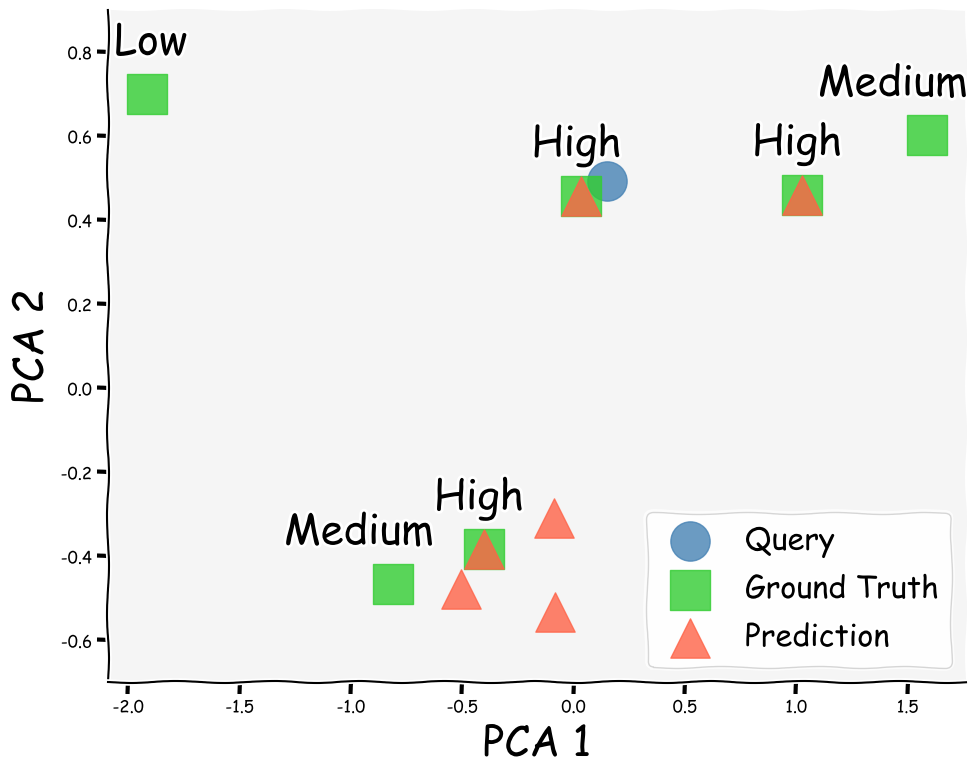

In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
from matplotlib import rcParams

# Specify the font path manually
rcParams['font.family'] = '/Users/spangher/Downloads/Humor-Sans.ttf'

# Assuming embed_documents function returns numpy arrays of embeddings
plt.xkcd()
def plot_embeddings(all_query_txts, all_gt_source_txts, all_pred_source_txts, all_gt_central, all_pred_central, number_pick):
    pca = PCA(n_components=2)  # PCA model to reduce to 2 dimensions

    # Embed and transform the selected texts
    query_txt = all_query_txts[number_pick]
    gt_source_txts = all_gt_source_txts[number_pick]
    pred_source_txts = all_pred_source_txts[number_pick]

    query_embedding = embed_documents([query_txt])
    gt_embeddings = embed_documents(gt_source_txts)
    pred_embeddings = embed_documents(pred_source_txts)

    # Prepare embeddings
    all_embeddings = np.vstack([query_embedding, gt_embeddings, pred_embeddings])

    # Standardize the embeddings
    scaler = StandardScaler()
    all_embeddings_scaled = scaler.fit_transform(all_embeddings)

    # Apply PCA
    reduced_embeddings = pca.fit_transform(all_embeddings_scaled)

    # Split embeddings
    num_query = query_embedding.shape[0]
    num_gt = gt_embeddings.shape[0]
    num_pred = pred_embeddings.shape[0]

    idx_query = 0
    idx_gt = idx_query + num_query
    idx_pred = idx_gt + num_gt
    scale_facor = 10
    query_pca = reduced_embeddings[idx_query:idx_gt]/scale_facor
    gt_pca = reduced_embeddings[idx_gt:idx_pred]/scale_facor
    pred_pca = reduced_embeddings[idx_pred:]/scale_facor
    data = "[[-0.40421057, -0.38321656], [1.58748, 0.60158], [-0.809756, -0.46567998], [0.03405856, 0.4577481], [-1.9154453, 0.7], [1.0246652, 0.46074295]]"
    gt_pca = np.array(eval(data))

    data = "[[-0.40421027, -0.3832165], [-0.50399005, -0.47675815], [1.0246654, 0.46074304], [-0.08266175, -0.532428], [-0.08705929, -0.309208], [0.03405856, 0.4577481]]"
    pred_pca = np.array(eval(data))
    plt.figure(figsize=(10, 8))#, dpi=300)
    ax = plt.gca()
    
    # Set gray background

    # Define markers and colors
    colors = ['steelblue', 'tomato', 'limegreen']  # Tomato, SteelBlue, Gold
    markers = {'Query': 'o', 'Ground Truth': 's', 'Prediction': '^'}

    # Plot data points
    ax.scatter(query_pca[:, 0], query_pca[:, 1], color=colors[0], marker=markers['Query'],
               label='Query', s=800, alpha=0.8)
    ax.scatter(gt_pca[:, 0], gt_pca[:, 1], color=colors[2], marker=markers['Ground Truth'],
               label='Ground Truth', s=800, alpha=0.8)
    ax.scatter(pred_pca[:, 0], pred_pca[:, 1], color=colors[1], marker=markers['Prediction'],
               label='Prediction', s=800, alpha=0.8)

    # Annotations
    all_points = gt_pca
    all_points_central = all_gt_central[number_pick] 
    visited = set()
    all_points_central = ['High', 'Medium', 'Medium', 'High', 'Low', 'High']
    
    for num, coordinate in enumerate(all_points):
        coord_tuple = tuple(coordinate)
        if coord_tuple not in visited:
            visited.add(coord_tuple)
            ax.annotate(
                f'{all_points_central[num]}',
                xy=(coordinate[0]+0.15, coordinate[1]+0.05),
                xytext=(5, 5),
                textcoords='offset points',
                ha='right', va='bottom',
                fontsize=30
            )
    
    # Legend adjustment
    ax.legend(fontsize=12, loc='lower right', frameon=True, prop={'size': 22})

    # Titles and labels
#     plt.title('PCA of Query, Ground Truth, and Prediction Embeddings', fontsize=20)
    plt.xlabel('PCA 1', fontsize=30)
    plt.ylabel('PCA 2', fontsize=30)
    print(gt_pca)
#     ax.set_xlim(-1,0.5)
    ax.set_ylim(-0.7,0.9)
    # Adjust tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12)

    # Remove top and right spines
    sns.despine(ax=ax)

    # Ensure layout is tight
    plt.tight_layout()
    ax.set_facecolor('whitesmoke')
    sns.set_style("whitegrid", {'axes.facecolor': 'whitesmoke'})

    # Show the plot
    plt.show()

# Example usage
picked = [
    # 25,
    38
]
for i in picked:
    print("The number pick is ", i)
    plot_embeddings(
        all_query_txts, 
        all_gt_source_txts, 
        all_pred_source_txts,
        all_gt_central,
        all_pred_central,
        i
)

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

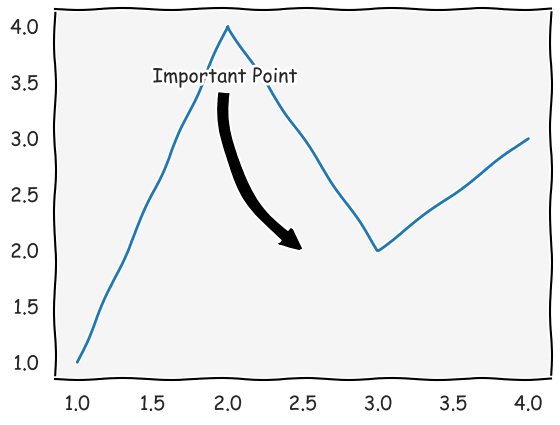

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.xkcd()
picked = [
    # 25,
    38
]
fig, ax = plt.subplots()

# Data for the plot
x = [1, 2, 3, 4]
y = [1, 4, 2, 3]
ax.plot(x, y)

# Create a curved arrow
arrow_style = "Simple, tail_width=0.5, head_width=1, head_length=1"
connection_style = "arc3,rad=0.3"  # Adjust the curvature with 'rad'
arrow_props = {
    "arrowstyle": arrow_style,
    "connectionstyle": connection_style,
    "color": "black"
}

# Add the arrow to the plot
ax.annotate("Important Point",
            xy=(2.5, 2),  # Point to annotate
            xytext=(1.5, 3.5),  # Text position
            arrowprops=arrow_props)

plt.show()

In [19]:
import warnings
warnings.filterwarnings('ignore', message="findfont: Font family 'Comic Neue' not found.")
warnings.filterwarnings('ignore', message="findfont: Font family 'xkcd' not found.")
warnings.filterwarnings('ignore', message="findfont: Font family 'xkcd Script' not found.")
warnings.filterwarnings('ignore', message="findfont")

In [20]:
import os 
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

In [21]:
# sudo cp /Users/spangher/Downloads/Humor-Sans.ttf /usr/share/fonts
# fc-cache -f -v

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

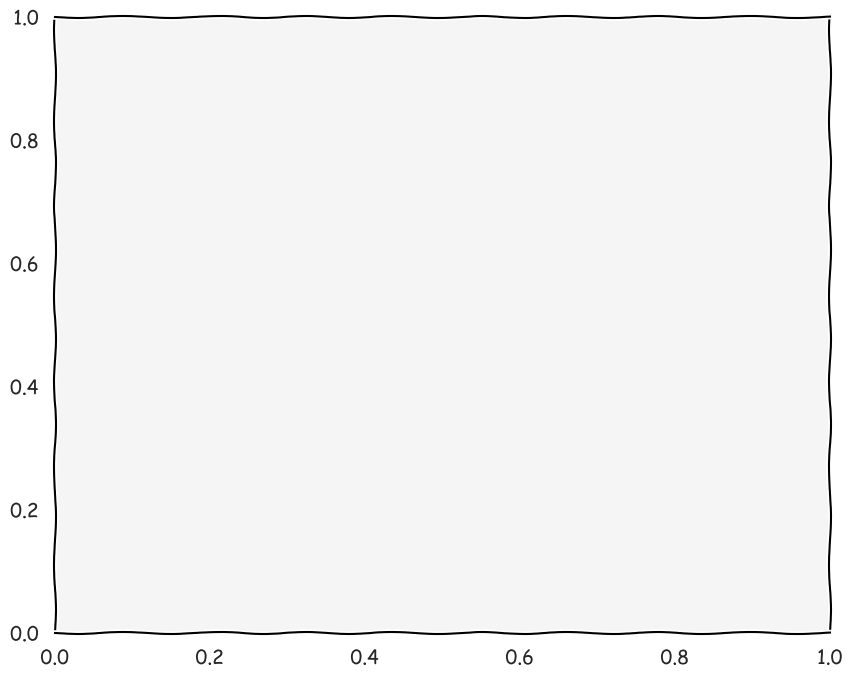

In [22]:
number_pick = 38

pca = PCA(n_components=2)  # PCA model to reduce to 2 dimensions

# Embed and transform the selected texts
query_txt = all_query_txts[number_pick]
gt_source_txts = all_gt_source_txts[number_pick]
pred_source_txts = all_pred_source_txts[number_pick]

query_embedding = embed_documents([query_txt])
gt_embeddings = embed_documents(gt_source_txts)
pred_embeddings = embed_documents(pred_source_txts)

# Prepare embeddings
all_embeddings = np.vstack([query_embedding, gt_embeddings, pred_embeddings])

# Standardize the embeddings
scaler = StandardScaler()
all_embeddings_scaled = scaler.fit_transform(all_embeddings)

# Apply PCA
reduced_embeddings = pca.fit_transform(all_embeddings_scaled)

# Split embeddings
num_query = query_embedding.shape[0]
num_gt = gt_embeddings.shape[0]
num_pred = pred_embeddings.shape[0]

idx_query = 0
idx_gt = idx_query + num_query
idx_pred = idx_gt + num_gt
scale_facor = 10
query_pca = reduced_embeddings[idx_query:idx_gt]/scale_facor
gt_pca = reduced_embeddings[idx_gt:idx_pred]/scale_facor
pred_pca = reduced_embeddings[idx_pred:]/scale_facor
data = "[[-0.40421057, -0.38321656], [1.58748, 0.60158], [-0.809756, -0.46567998], [0.03405856, 0.4577481], [-1.9154453, 0.7], [1.0246652, 0.46074295]]"
gt_pca = np.array(eval(data))
data = "[[-0.40421027, -0.3832165], [-0.50399005, -0.47675815], [1.0246654, 0.46074304], [-0.08266175, -0.532428], [-0.08705929, -0.309208], [0.03405856, 0.4577481]]"
pred_pca = np.array(eval(data))
plt.figure(figsize=(10, 8))#, dpi=300)
ax = plt.gca()

# Set gray background

# Define markers and colors
colors = ['steelblue', 'tomato', 'limegreen']  # Tomato, SteelBlue, Gold
markers = {'Query': 'o', 'Ground Truth': 's', 'Prediction': '^'}

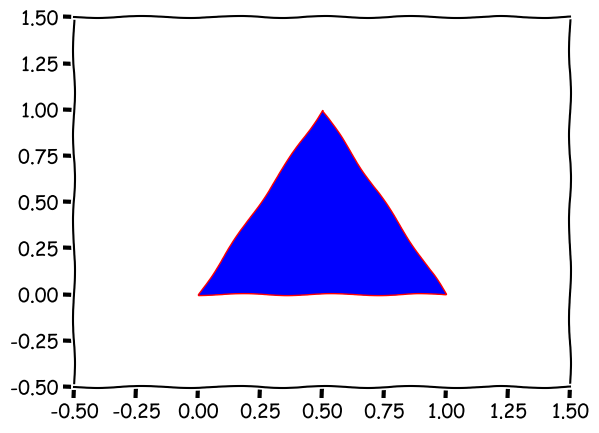

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots()

# Define the vertices of the triangle
vertices = [(0, 0), (.5, 1), (1, 0)]

# Create the triangle patch
triangle = patches.Polygon(vertices, closed=True, facecolor='blue', edgecolor='red')

# Add the triangle patch to the axes
ax.add_patch(triangle)

# Set the axis limits
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)

# Show the plot
plt.show()

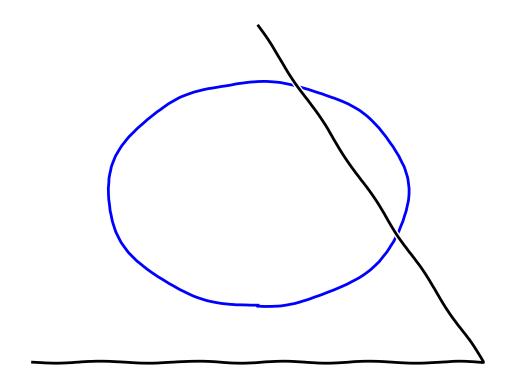

In [18]:
from matplotlib.patches import Circle, Tri

fig, ax = plt.subplots()

# Define the triangle vertices
x = [0.2, 0.8, 0.5]
y = [0.2, 0.2, 0.8]

# Draw the triangle
ax.plot(x, y, 'k-', lw=2)

# Remove axes and ticks
ax.set_xticks([])
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Define circle properties
circle = Circle((0.5, 0.5), radius=0.2, color='blue', fill=False, linewidth=2)
# Add circle to plot
ax.add_patch(circle)

plt.show()

In [32]:
t = np.vstack([query_pca, gt_pca, pred_pca])

In [36]:
t_min = t.min(axis=0)
t_max = t.max(axis=0)

In [37]:
t_min

array([-1.9154453, -0.532428 ])

In [ ]:
x - x_min / x_max - x_min 

In [47]:
markers

{'Query': 'o', 'Ground Truth': 's', 'Prediction': '^'}

In [58]:
query_pca = np.array([[0.15024199, 0.49204955]]).squeeze()
query_pca = (query_pca - t_min) / (t_max - t_min)
query_x, query_y = query_pca

gt_pca = np.array([[-0.40421057, -0.38321656],
       [ 1.58748   ,  0.60158   ],
       [-0.809756  , -0.46567998],
       [ 0.03405856,  0.4577481 ],
       [-1.9154453 ,  0.7       ],
       [ 1.0246652 ,  0.46074295]])
gt_pca = (gt_pca - t_min) / (t_max - t_min)

pred_pca = np.array([[-0.40421027, -0.3832165 ],
       [-0.50399005, -0.47675815],
       [ 1.0246654 ,  0.46074304],
       [-0.08266175, -0.532428  ],
       [-0.08705929, -0.309208  ],
       [ 0.03405856,  0.4577481 ]])

pred_pca = (pred_pca - t_min) / (t_max - t_min)

In [67]:
import numpy as np 

In [70]:
# query_pca = [0.5, 0.83126767]
query_pca = [0.5, 0.5]
pred_pca = np.array([
   [0.43142086, 0.12107117],
   [0.40293615, 0.04517087],
   [0.83933012, 0.80586536],
   [0.52321514, 0.        ],
   [0.52195975, 0.18112214],
   [0.55653595, 0.80343525]
])
gt_pca = np.array([
   [0.43142077, 0.12107112],
   [1.        , 0.92014138],
   [0.31564741, 0.05415977],
   [0.55653595, 0.80343525],
   [0.        , 1.        ],
   [0.83933006, 0.80586529]
])

In [83]:
colors

['steelblue', 'tomato', 'limegreen']

In [94]:
query_x, query_y = [.5, .5]
pred_pca = query_pca - np.random.uniform(low=-.2, high=.2, size=pred_pca.shape)

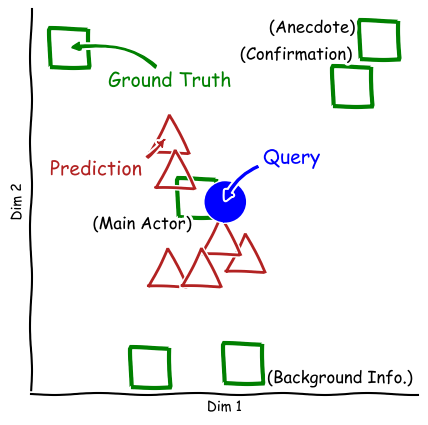

In [172]:
import numpy as np 


plt.figure(figsize=(5, 5))#, dpi=300)
ax = plt.gca()

gt_pca = np.array([
   [0.43, 0.51],
    # 
   [0.31, 0.07],
   [0.55, 0.08],
   #
   [.1 , .9  ],
   [.9  , 0.92],
   [0.83, 0.80]
])
pred_pca = [
    [0.55405175, 0.36774142],
    [0.49076704, 0.41302088],
    [0.35808786, 0.67640491],
    [0.35395099, 0.32953879],
    [0.37299014, 0.58505022],
    [0.44086117, 0.33007826]
]


# Create a curved arrow
arrow_props = {
    "arrowstyle": "Simple, tail_width=0.1, head_width=.4, head_length=.4",
    "connectionstyle": "arc3,rad=0.3",
    "color": "green"
}
ax.annotate("Ground Truth",
            xy=[.1 , .9],  # Point to annotate
            xytext=(.2, .8),  # Text position
            arrowprops=arrow_props, color='green')

arrow_props = {
    "arrowstyle": "Simple, tail_width=0.1, head_width=.4, head_length=.4",
    "connectionstyle": "arc3,rad=0.3",
    "color": "blue"
}
ax.annotate("Query",
            xy=[.5 , .5],  # Point to annotate
            xytext=(.6, .6),  # Text position
            arrowprops=arrow_props, color='blue')

arrow_props = {
    "arrowstyle": "Simple, tail_width=0.1, head_width=.4, head_length=.4",
    "connectionstyle": "arc3,rad=0.3",
    "color": "firebrick"
}
ax.annotate("Prediction",
            xy=[0.35, 0.67],  # Point to annotate
            xytext=[0.35 -.3, 0.67-.1],  # Text position
            arrowprops=arrow_props, color='firebrick')

for gt_x, gt_y in gt_pca:
    square = patches.Rectangle((gt_x-.05, gt_y-.05), 0.1, 0.1, linewidth=3, edgecolor='green', facecolor='none')
    ax.add_patch(square)

for pred_x, pred_y in pred_pca:
    offset = .05
    vertices = [(pred_x- offset , pred_y - offset), (pred_x, pred_y + offset), (pred_x + offset, pred_y - offset)]
    triangle = patches.Polygon(vertices, closed=True, facecolor='none', linewidth=2, edgecolor='firebrick')
    ax.add_patch(triangle)

circle = Circle((query_x, query_y), radius=0.05, color='blue', fill=True, linewidth=2)
ax.add_patch(circle)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([])
plt.xlabel('Dim 1',  fontsize=10)
plt.ylabel('Dim 2', fontsize=10)
plt.yticks([])


ax.annotate("(Anecdote)", xy=[0.9 -.285, 0.92+.02] , color='black', style='italic', fontsize=12)
ax.annotate("(Confirmation)", xy=[0.9 -.36, 0.92-.05] , color='black', style='italic', fontsize=12)
ax.annotate("(Background Info.)", xy=[0.31+.3, 0.03] , color='black', style='italic', fontsize=12)
ax.annotate("(Main Actor)", xy=[0.16, 0.43] , color='black', style='italic', fontsize=12)
plt.savefig('../latex/naacl2024/figures/cover_photo.png', bbox_inches='tight')

In [150]:
pred_pca

array([[0.55405175, 0.36774142],
       [0.49076704, 0.41302088],
       [0.35808786, 0.67640491],
       [0.35395099, 0.32953879],
       [0.37299014, 0.53505022],
       [0.44086117, 0.33007826]])

In [118]:
gt_pca

array([[0.43, 0.51],
       [0.31, 0.05],
       [0.55, 0.08],
       [0.1 , 0.9 ],
       [0.9 , 0.92],
       [0.83, 0.8 ]])

In [7]:
colors = ['steelblue', 'tomato', 'limegreen']  # Tomato, SteelBlue, Gold
markers = {'Query': 'o', 'Ground Truth': 's', 'Prediction': '^'}

In [16]:
import warnings
import numpy as np
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
warnings.filterwarnings("ignore", module="matplotlib")
warnings.simplefilter("ignore")

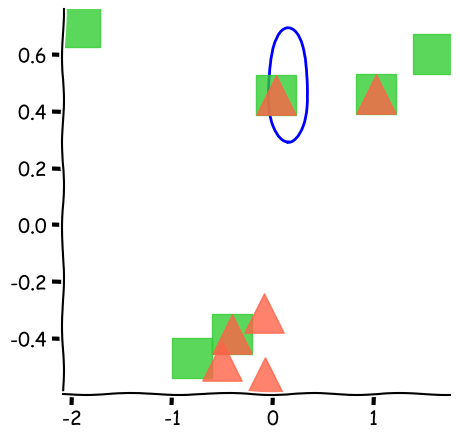

In [25]:
# Plot data points
import matplotlib.pyplot as plt
plt.xkcd()
plt.figure(figsize=(5, 5))#, dpi=300)
ax = plt.gca()

## query
circle = Circle((query_x, query_y), radius=0.2, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

# vertices = [(0, 0), (.5, 1), (1, 0)]
# triangle = patches.Polygon(vertices, closed=True, facecolor='blue', edgecolor='red')
# ax.add_patch(triangle)
# ax.set_xlim(-0.5, 1.5)
# ax.set_ylim(-0.5, 1.5)

# Show the plot
# plt.show()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.scatter(gt_pca[:, 0], gt_pca[:, 1], color=colors[2], marker=markers['Ground Truth'],
           label='Ground Truth', s=800, alpha=0.8)
ax.scatter(pred_pca[:, 0], pred_pca[:, 1], color=colors[1], marker=markers['Prediction'],
           label='Prediction', s=800, alpha=0.8)

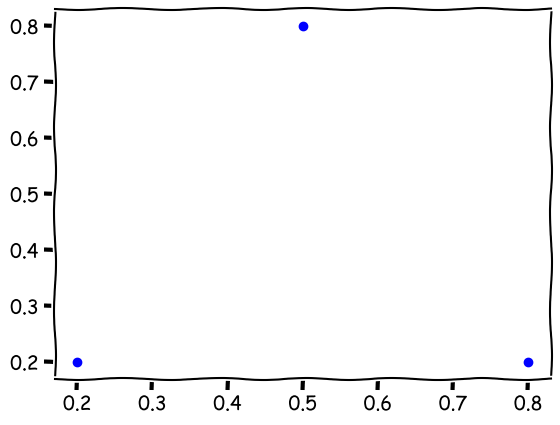

In [90]:
# Create the scatter plot
plt.scatter(x, y, color='blue', marker='o')

# Add labels and title
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
# plt.title('XKCD Scatter Plot')

# Show the plot
# plt.show()
